# FinanceAI — EDA del Dataset Híbrido
**Team 38 (LATAM) · Oracle ONE G9**

Este notebook construye el dataset híbrido (Capa 1: transacciones reales + Capa 2: perfil financiero sintético) y realiza un análisis exploratorio (EDA) inicial para el Sprint 1.

**Cómo usar en Google Colab:**
1. Corre la celda de instalación de dependencias.
2. Sube tu `kaggle.json` cuando se te pida (Kaggle → Account → Create New API Token), **o** sube directamente los CSV crudos a `data/raw/` si ya los tienes.
3. Corre el resto de las celdas en orden.

> Si el equipo ya generó `financeai_dataset_hibrido.csv` con `build_dataset_financeai.py`, puedes saltar directo a la sección **3. Cargar dataset final** subiendo ese archivo.


## 1. Configuración del entorno

In [12]:
# Instalación de dependencias (Colab ya trae pandas/numpy/matplotlib/seaborn)
!pip install -q kaggle faker


In [13]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

RAW_DIR = Path("data/raw")
PROCESSED_DIR = Path("data/processed")
RAW_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

CATEGORIAS_PROYECTO = [
    "Alimentación", "Transporte", "Salud", "Vivienda",
    "Educación", "Ocio", "Servicios", "Otros",
]
print("Entorno listo.")


Entorno listo.


## 2. Construir el dataset híbrido

Esta sección reutiliza la misma lógica de `build_dataset_financeai.py` (Capa 1 + Capa 2).
Si ya tienes `financeai_dataset_hibrido.csv` generado previamente, sube el archivo y salta a la
sección **3**.


### 2.1 Subir credenciales de Kaggle y descargar las fuentes (opcional si ya tienes los CSV)

In [14]:
# En Colab: descomenta para subir tu kaggle.json y descargar automáticamente
# from google.colab import files
# uploaded = files.upload()  # selecciona tu kaggle.json
# import os, shutil
# os.makedirs("/root/.kaggle", exist_ok=True)
# shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# os.chmod("/root/.kaggle/kaggle.json", 0o600)

import subprocess

RUTA_CAPA1 = RAW_DIR / "financial_transactions.csv"
RUTA_CAPA2 = RAW_DIR / "personal_finance_ml.csv"

def descargar_si_falta():
    datasets = {
        RUTA_CAPA1: "artemkabseu/financial-transactions-dataset-expenses-and-income",
        RUTA_CAPA2: "miadul/personal-finance-ml-dataset",
    }
    for ruta, slug in datasets.items():
        if ruta.exists():
            print(f"Ya existe: {ruta}")
            continue
        try:
            subprocess.run(
                ["kaggle", "datasets", "download", "-d", slug, "-p", str(RAW_DIR), "--unzip"],
                check=True,
            )
        except Exception as e:
            print(f"No se pudo descargar {slug} automáticamente ({e}).")
            print("Sube el CSV manualmente a data/raw/ con el nombre esperado, o usa files.upload() en Colab.")

descargar_si_falta()


### 2.2 Mapeo de categorías (Capa 1)

In [15]:
# IMPORTANTE: ajustar estas llaves según los valores reales de la columna "category"
# del CSV descargado (revisar con df["category"].unique() antes de usar en producción).
MAPEO_CATEGORIAS = {
    "groceries": "Alimentación", "restaurant": "Alimentación", "food": "Alimentación",
    "supermarket": "Alimentación",
    "transport": "Transporte", "fuel": "Transporte", "taxi": "Transporte",
    "public transport": "Transporte",
    "health": "Salud", "pharmacy": "Salud", "medical": "Salud",
    "rent": "Vivienda", "housing": "Vivienda", "mortgage": "Vivienda",
    "utilities": "Servicios", "bills": "Servicios", "internet": "Servicios",
    "education": "Educación", "tuition": "Educación", "books": "Educación",
    "entertainment": "Ocio", "streaming": "Ocio", "leisure": "Ocio",
    "shopping": "Otros", "other": "Otros",
}

def cargar_capa1_transacciones(path_csv):
    df = pd.read_csv(path_csv)
    df = df.rename(columns={
        "date": "fecha", "description": "descripcion",
        "category": "categoria_original", "amount": "valor",
    })
    df["categoria"] = (
        df["categoria_original"].astype(str).str.strip().str.lower()
        .map(MAPEO_CATEGORIAS).fillna("Otros")
    )
    df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")
    df["valor"] = pd.to_numeric(df["valor"], errors="coerce").abs()
    return df.dropna(subset=["valor"])[["fecha", "descripcion", "categoria", "valor"]].reset_index(drop=True)


def asignar_usuarios(df_transacciones, n_usuarios=500):
    usuario_ids = [f"user_{i:04d}" for i in range(n_usuarios)]
    pesos = np.random.dirichlet(np.ones(n_usuarios) * 2)
    df = df_transacciones.copy()
    df["usuario_id"] = np.random.choice(usuario_ids, size=len(df), p=pesos)
    return df, usuario_ids


### 2.3 Perfil financiero sintético (Capa 2) y función de scoring

In [16]:
def cargar_capa2_referencia(path_csv):
    df = pd.read_csv(path_csv)
    df = df.rename(columns={
        "monthly_income_usd": "ingreso_mensual",
        "debt_to_income_ratio": "nivel_endeudamiento",
        "savings_to_income_ratio": "ratio_ahorro",
        "credit_score": "score_crediticio",
    })
    cols = ["ingreso_mensual", "nivel_endeudamiento", "ratio_ahorro", "score_crediticio"]
    return df[cols].dropna()


def generar_perfiles_sinteticos(usuario_ids, df_referencia):
    muestra = df_referencia.sample(n=len(usuario_ids), replace=True, random_state=RANDOM_SEED).reset_index(drop=True)
    muestra["usuario_id"] = usuario_ids
    ruido = np.random.uniform(0.9, 1.1, size=len(muestra))
    muestra["ingreso_mensual"] = (muestra["ingreso_mensual"] * ruido).round(2)
    muestra["nivel_endeudamiento"] = muestra["nivel_endeudamiento"].clip(0, 1)
    muestra["frecuencia_ahorro"] = pd.cut(
        muestra["ratio_ahorro"], bins=[-np.inf, 0.05, 0.15, np.inf],
        labels=["Baja", "Media", "Alta"],
    ).astype(str)
    return muestra[["usuario_id", "ingreso_mensual", "nivel_endeudamiento", "frecuencia_ahorro", "score_crediticio"]]


def calcular_perfil_financiero(row):
    riesgo = 0
    if row["ratio_gasto_ingreso"] > 0.9: riesgo += 2
    elif row["ratio_gasto_ingreso"] > 0.7: riesgo += 1
    if row["nivel_endeudamiento"] > 0.4: riesgo += 2
    elif row["nivel_endeudamiento"] > 0.25: riesgo += 1
    if row["frecuencia_ahorro"] == "Baja": riesgo += 1
    elif row["frecuencia_ahorro"] == "Alta": riesgo -= 1
    if riesgo >= 3: return "En riesgo"
    if riesgo >= 1: return "En observación"
    return "Saludable"


def generar_recomendaciones(row):
    recs = []
    if row["ratio_gasto_ingreso"] > 0.8:
        recs.append("Reducir gastos recurrentes en las categorías de mayor peso")
    if row["nivel_endeudamiento"] > 0.35:
        recs.append("Priorizar el pago de deuda antes de nuevos compromisos financieros")
    if row["frecuencia_ahorro"] == "Baja":
        recs.append("Aumentar la frecuencia de ahorro mensual")
    if not recs:
        recs.append("Mantener los hábitos financieros actuales")
    return recs


def construir_dataset_final(df_transacciones_usuario, df_perfiles):
    resumen = (
        df_transacciones_usuario.groupby(["usuario_id", "categoria"])["valor"]
        .sum().unstack(fill_value=0).reset_index()
    )
    for cat in CATEGORIAS_PROYECTO:
        if cat not in resumen.columns:
            resumen[cat] = 0.0

    df_final = df_perfiles.merge(resumen, on="usuario_id", how="left")
    df_final[CATEGORIAS_PROYECTO] = df_final[CATEGORIAS_PROYECTO].fillna(0.0)
    df_final["gasto_total"] = df_final[CATEGORIAS_PROYECTO].sum(axis=1)
    df_final["ratio_gasto_ingreso"] = (
        df_final["gasto_total"] / df_final["ingreso_mensual"].replace(0, np.nan)
    ).fillna(0)
    df_final["perfil_financiero"] = df_final.apply(calcular_perfil_financiero, axis=1)
    df_final["recomendaciones"] = df_final.apply(generar_recomendaciones, axis=1)
    return df_final


### 2.4 Ejecutar el pipeline

In [17]:
if RUTA_CAPA1.exists() and RUTA_CAPA2.exists():
    df_transacciones = cargar_capa1_transacciones(RUTA_CAPA1)
    df_transacciones_usuario, usuario_ids = asignar_usuarios(df_transacciones)
    df_referencia = cargar_capa2_referencia(RUTA_CAPA2)
    df_perfiles = generar_perfiles_sinteticos(usuario_ids, df_referencia)
    df = construir_dataset_final(df_transacciones_usuario, df_perfiles)
    df.to_csv(PROCESSED_DIR / "financeai_dataset_hibrido.csv", index=False)
    print(f"Dataset construido: {df.shape[0]} usuarios, {df.shape[1]} columnas")
else:
    print("No se encontraron los CSV crudos. Sube 'financeai_dataset_hibrido.csv' directamente en la sección 3.")


No se encontraron los CSV crudos. Sube 'financeai_dataset_hibrido.csv' directamente en la sección 3.


## 3. Cargar dataset final

In [18]:
ruta_final = PROCESSED_DIR / "financeai_dataset_hibrido.csv"
if ruta_final.exists():
    df = pd.read_csv(ruta_final)
    print(f"Dataset cargado: {df.shape[0]} usuarios, {df.shape[1]} columnas")
    df.head()
else:
    print("No se encontró el dataset procesado. Ejecuta la sección 2 o sube el CSV a data/processed/.")


Dataset cargado: 500 usuarios, 17 columnas


## 4. Panorama general (EDA)

In [19]:
print("Dimensiones:", df.shape)
print()
print("Tipos de dato:")
print(df.dtypes)


Dimensiones: (500, 17)

Tipos de dato:
usuario_id              object
ingreso_mensual        float64
nivel_endeudamiento    float64
frecuencia_ahorro       object
score_crediticio         int64
Alimentación           float64
Ocio                   float64
Otros                  float64
Salud                  float64
Transporte             float64
Vivienda               float64
Educación              float64
Servicios              float64
gasto_total            float64
ratio_gasto_ingreso    float64
perfil_financiero       object
recomendaciones         object
dtype: object


In [20]:
print("Valores nulos por columna:")
print(df.isna().sum())


Valores nulos por columna:
usuario_id             0
ingreso_mensual        0
nivel_endeudamiento    0
frecuencia_ahorro      0
score_crediticio       0
Alimentación           0
Ocio                   0
Otros                  0
Salud                  0
Transporte             0
Vivienda               0
Educación              0
Servicios              0
gasto_total            0
ratio_gasto_ingreso    0
perfil_financiero      0
recomendaciones        0
dtype: int64


In [21]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
ingreso_mensual,500.0,4047.763160,1908.513627,451.24,2699.285,4002.275000,5287.345000,9270.700000
nivel_endeudamiento,500.0,0.298000,0.428380,0.00,0.000,0.000000,0.812500,1.000000
score_crediticio,500.0,573.882000,160.098855,300.00,445.500,570.500000,721.250000,849.000000
Alimentación,500.0,3.076000,15.754321,0.00,0.000,0.000000,0.000000,313.000000
Ocio,500.0,1.890000,12.750964,0.00,0.000,0.000000,0.000000,232.000000
Otros,500.0,20.578000,119.887355,0.00,0.000,0.000000,8.000000,1810.000000
Salud,500.0,1.608000,11.859495,0.00,0.000,0.000000,0.000000,201.000000
Transporte,500.0,2.568000,5.314307,0.00,0.000,1.000000,2.000000,35.000000
Vivienda,500.0,0.000000,0.000000,0.00,0.000,0.000000,0.000000,0.000000
Educación,500.0,0.000000,0.000000,0.00,0.000,0.000000,0.000000,0.000000


## 5. Distribución de variables clave

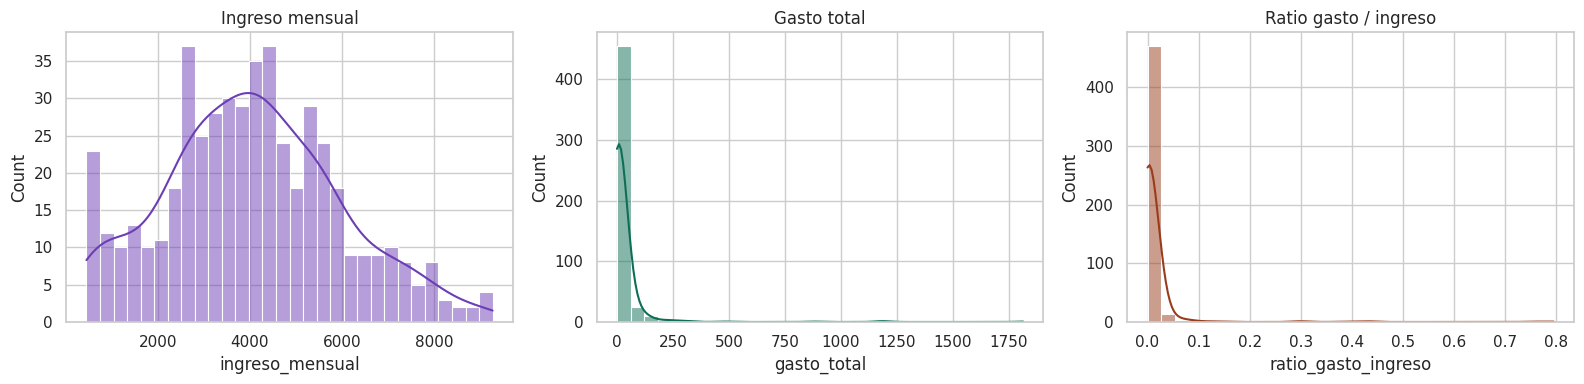

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
sns.histplot(df["ingreso_mensual"], bins=30, kde=True, ax=axes[0], color="#6C3EB5")
axes[0].set_title("Ingreso mensual")

sns.histplot(df["gasto_total"], bins=30, kde=True, ax=axes[1], color="#0F6E56")
axes[1].set_title("Gasto total")

sns.histplot(df["ratio_gasto_ingreso"], bins=30, kde=True, ax=axes[2], color="#993C1D")
axes[2].set_title("Ratio gasto / ingreso")

plt.tight_layout()
plt.show()


### 5.1 Distribución del perfil financiero

/tmp/ipykernel_1056/1526138179.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="perfil_financiero", order=orden, palette=["#0F6E56", "#6C3EB5", "#993C1D"])


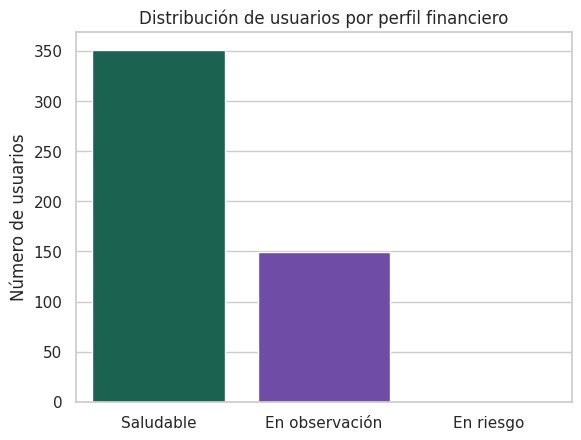

perfil_financiero
Saludable         70.2
En observación    29.8
Name: proportion, dtype: float64


In [23]:
orden = ["Saludable", "En observación", "En riesgo"]
ax = sns.countplot(data=df, x="perfil_financiero", order=orden, palette=["#0F6E56", "#6C3EB5", "#993C1D"])
ax.set_title("Distribución de usuarios por perfil financiero")
ax.set_xlabel("")
ax.set_ylabel("Número de usuarios")
plt.show()

print(df["perfil_financiero"].value_counts(normalize=True).round(3) * 100)


### 5.2 Gasto promedio por categoría

/tmp/ipykernel_1056/1895727062.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=gasto_promedio.values, y=gasto_promedio.index, palette="mako")


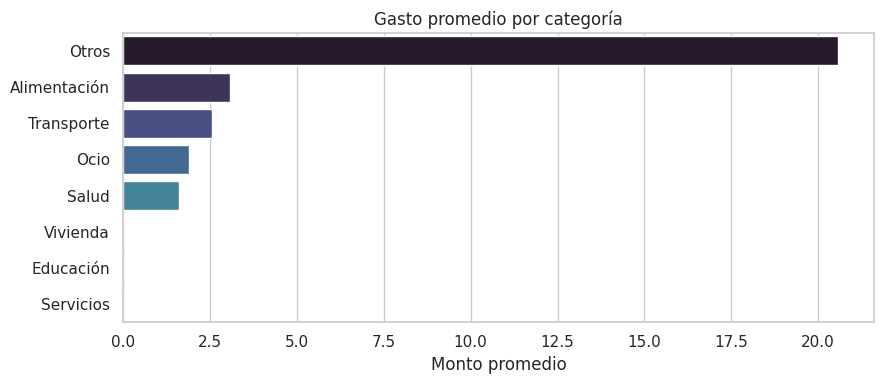

In [24]:
gasto_promedio = df[CATEGORIAS_PROYECTO].mean().sort_values(ascending=False)

plt.figure(figsize=(9, 4))
sns.barplot(x=gasto_promedio.values, y=gasto_promedio.index, palette="mako")
plt.title("Gasto promedio por categoría")
plt.xlabel("Monto promedio")
plt.ylabel("")
plt.tight_layout()
plt.show()


### 5.3 Relación entre variables (correlación)

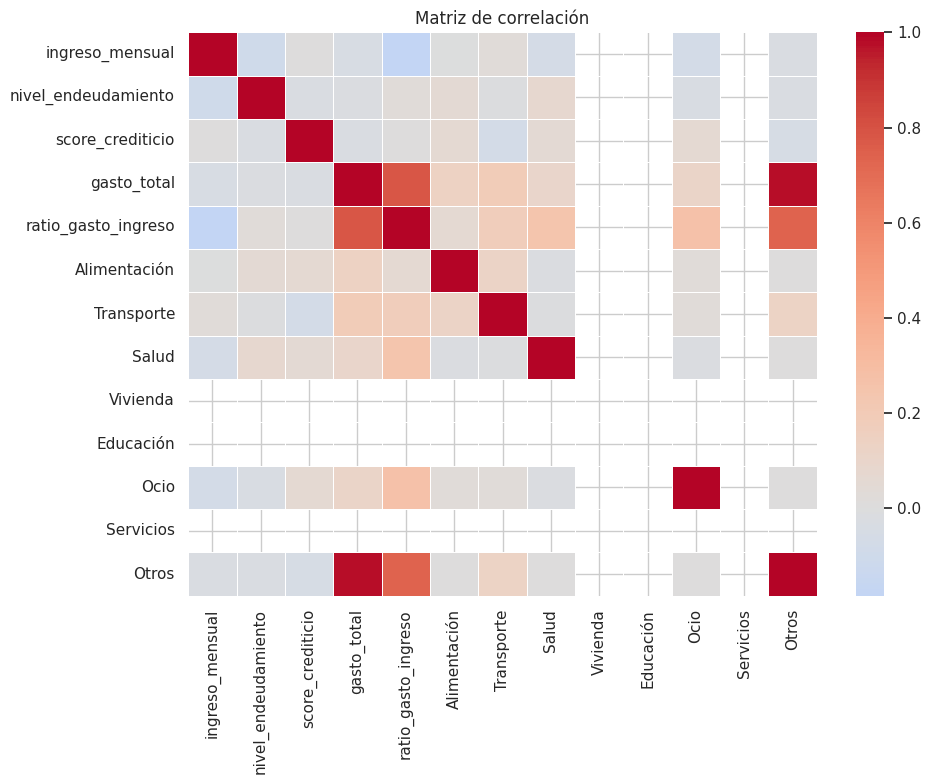

In [25]:
num_cols = ["ingreso_mensual", "nivel_endeudamiento", "score_crediticio",
            "gasto_total", "ratio_gasto_ingreso"] + CATEGORIAS_PROYECTO

plt.figure(figsize=(10, 8))
corr = df[num_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.4)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


### 5.4 Endeudamiento y ratio de gasto por perfil financiero

/tmp/ipykernel_1056/3828976915.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="perfil_financiero", y="nivel_endeudamiento", order=orden, ax=axes[0], palette=["#0F6E56", "#6C3EB5", "#993C1D"])
/tmp/ipykernel_1056/3828976915.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="perfil_financiero", y="ratio_gasto_ingreso", order=orden, ax=axes[1], palette=["#0F6E56", "#6C3EB5", "#993C1D"])


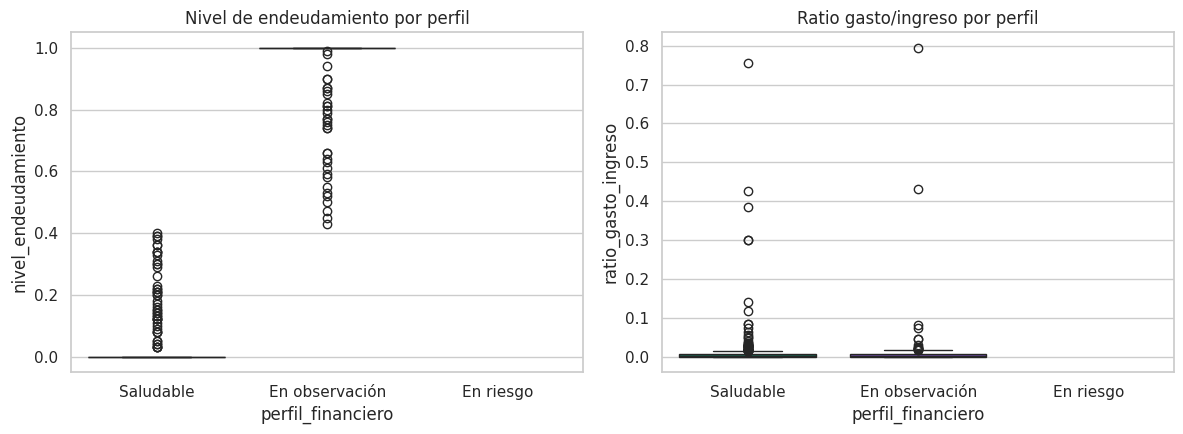

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.boxplot(data=df, x="perfil_financiero", y="nivel_endeudamiento", order=orden, ax=axes[0], palette=["#0F6E56", "#6C3EB5", "#993C1D"])
axes[0].set_title("Nivel de endeudamiento por perfil")

sns.boxplot(data=df, x="perfil_financiero", y="ratio_gasto_ingreso", order=orden, ax=axes[1], palette=["#0F6E56", "#6C3EB5", "#993C1D"])
axes[1].set_title("Ratio gasto/ingreso por perfil")

plt.tight_layout()
plt.show()


### 5.5 Recomendaciones más frecuentes

/tmp/ipykernel_1056/4058460489.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=conteo_recs.values, y=conteo_recs.index, palette="crest")


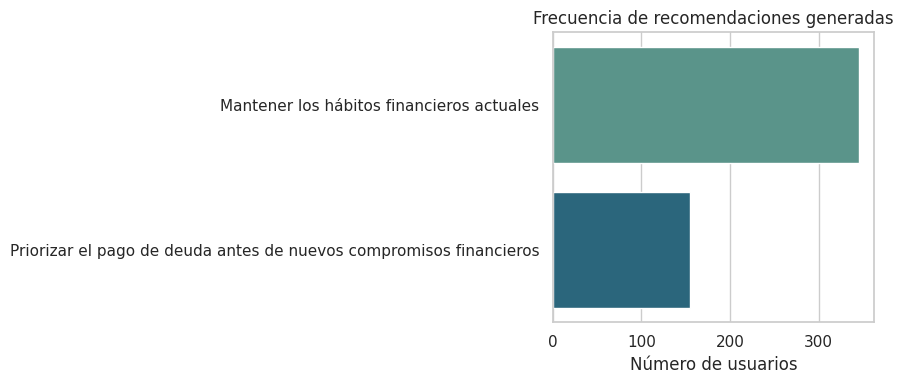

In [27]:
import ast

recs = df["recomendaciones"]
if recs.dtype == object and isinstance(recs.iloc[0], str):
    recs = recs.apply(ast.literal_eval)

todas_recs = recs.explode()
conteo_recs = todas_recs.value_counts()

plt.figure(figsize=(9, 4))
sns.barplot(x=conteo_recs.values, y=conteo_recs.index, palette="crest")
plt.title("Frecuencia de recomendaciones generadas")
plt.xlabel("Número de usuarios")
plt.ylabel("")
plt.tight_layout()
plt.show()


## Explicación del Notebook: Dataset Híbrido y EDA

Este notebook tiene como objetivo principal la creación y el análisis exploratorio (EDA) de un **Dataset Financiero Híbrido** diseñado para el proyecto FinanceAI.

### Para el Equipo de Data Science (DS):

*   **Construcción del Dataset**: Se combinan dos fuentes de datos:
    *   **Capa 1**: Transacciones financieras reales (obtenidas de Kaggle), que se categorizan y se asignan a usuarios sintéticos.
    *   **Capa 2**: Perfiles financieros sintéticos (también de Kaggle), que incluyen `ingreso_mensual`, `nivel_endeudamiento`, `ratio_ahorro` y `score_crediticio`.
*   **Ingeniería de Características**: Se calculan nuevas variables como `gasto_total`, `ratio_gasto_ingreso`, y se define un `perfil_financiero` (Saludable, En observación, En riesgo) basado en reglas de negocio.
*   **Generación de Recomendaciones**: Se crean recomendaciones financieras básicas para cada usuario.
*   **EDA Inicial**: Se realizan visualizaciones y estadísticas descriptivas para entender la distribución de variables clave (`ingreso_mensual`, `gasto_total`, `ratio_gasto_ingreso`), la composición de los perfiles financieros, el gasto promedio por categoría y las correlaciones entre variables numéricas. Esto es crucial para la próxima fase de modelado.

### Para el Equipo de Backend:

*   **Pipeline de Generación de Datos**: El notebook contiene la lógica completa para construir el dataset `financeai_dataset_hibrido.csv` a partir de las fuentes crudas. Esta lógica es replicable y se puede adaptar para generar datasets de entrenamiento o para probar nuevas reglas de negocio.
*   **Estructura del Dataset Final**: El archivo `financeai_dataset_hibrido.csv` es el *output principal*. Contiene `usuario_id`, datos de perfil (`ingreso_mensual`, `nivel_endeudamiento`, `score_crediticio`, `frecuencia_ahorro`), el desglose de gastos por categoría, el `gasto_total`, `ratio_gasto_ingreso`, `perfil_financiero` y una lista de `recomendaciones` por usuario. Esta será la entrada para los modelos y el API.
*   **Consideraciones de Integración**: Las `recomendaciones` se generan como una lista de strings. Se debe considerar cómo serializar y deserializar esta información al integrar con el API.

### Para el Equipo de Frontend:

*   **Datos Clave del Usuario**: El dataset provee información enriquecida por usuario que puede ser visualizada en la interfaz de usuario:
    *   `ingreso_mensual`, `nivel_endeudamiento`, `score_crediticio`, `frecuencia_ahorro`.
    *   `perfil_financiero` (Saludable, En observación, En riesgo), que puede usarse para mostrar un estado rápido del usuario.
    *   `recomendaciones`: una lista de consejos personalizados que pueden mostrarse directamente al usuario.
    *   Desglose de gastos por `categoría` y `gasto_total` para gráficos y resúmenes.
*   **Representación Visual**: Las secciones de EDA muestran ejemplos de cómo se pueden visualizar estas métricas (histogramas, gráficos de barras, boxplots, mapas de calor) para ofrecer una experiencia rica al usuario.

### Solicitud de Feedback:

Nos gustaría obtener su retroalimentación sobre:

*   **Relevancia de las variables**: ¿Faltan datos importantes para su parte del proyecto?
*   **Interpretación de los perfiles y recomendaciones**: ¿Son claras y útiles las categorías de `perfil_financiero` y las `recomendaciones` generadas?
*   **Formato del Dataset**: ¿El `financeai_dataset_hibrido.csv` tiene la estructura adecuada para sus necesidades?

¡Gracias por su colaboración!

## 6. Notas y siguientes pasos

**Hallazgos preliminares (a completar por el equipo tras correr con los datos reales):**
- ¿Qué categoría concentra el mayor gasto promedio?
- ¿Qué tan desbalanceado está `perfil_financiero`? (relevante para elegir métricas de evaluación del modelo)
- ¿Hay correlación fuerte entre alguna categoría de gasto y el nivel de endeudamiento?

**Siguientes pasos (Semana 1):**
- Ingeniería de atributos para el clasificador de gastos (a partir de `descripcion`).
- Split train/test y primer modelo de clasificación (Scikit-Learn).
- Serialización del modelo para conectarlo al endpoint `/analisis-financiero` del equipo de Backend.
